In [1]:
import os
import sys
import pickle
import numpy as np
from numba import njit
import itertools as itt
import aerosandbox as asb

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from Aircraft.Planform import Planform
from Aircraft.Fixed import Fixed
from Drag.Fuselage import Fuselage
from Drag.Bay import Bay
from Drag.LandingGear import LandingGear
from Aircraft.Aircraft import Aircraft
from global_parameters import Assumptions
from Requirements.FuelReq import FuelReq
from Requirements.LGReq import LGReq
from Requirements.MassReq import MassReq
from Requirements.MDReq import MDReq
from Requirements.EmpennageReq import EmpennageReq
from Requirements.Requirement import Requirement
from EmpennageSizing.TailFinder import TailFinder
from EmpennageSizing.CanardFinder import CanardFinder
from structural_analysis.Material import Material

# Loading the pre-computed planforms and the fuselage

In [2]:
with open("pickles/planform_pickle_official.pcl", "r+b") as f:
    plaforms_recovered:list[tuple[Planform, str, bool]] = pickle.load(f)

assumptions = Assumptions()

In [3]:
# # --- Import Onshape pull utilities ---
# sys.path.append(os.path.abspath(os.getcwd()))
# from onshape_pull import (
#     fetch_variable_studio, fetch_measurement_features,
#     evaluate_measurements, load_cached_masses, fetch_mass_properties,
#     compute_cg_scenarios, lookup_var, lookup_meas,
#     UPDATE_MASSES,
# )

# # --- Pull data from Onshape ---
# variables = fetch_variable_studio()
# meas_names = fetch_measurement_features()
# measurements = evaluate_measurements(meas_names)
# components = load_cached_masses() if not UPDATE_MASSES else fetch_mass_properties()
# cg_data = compute_cg_scenarios(components)

# # --- Z offset (axle datum) ---
# Front_Landing_Gear_Hinge_Z = lookup_meas(measurements, "Front_Landing_Gear_Hinge_Z")
# Front_Strut_Height, _, _ = lookup_var(variables, "Front_Strut_Height")
# Front_Gear_Extension_Max = lookup_meas(measurements, "Front_Gear_Extension_Max")
# Front_Gear_Extension_Min = lookup_meas(measurements, "Front_Gear_Extension_Min")
# z_offset = (Front_Landing_Gear_Hinge_Z + Front_Strut_Height
#             + (Front_Gear_Extension_Max - Front_Gear_Extension_Min))

# # --- Build drag components ---
# engine_bay = Bay(
#     surface_wetted=83744.32631 / 1e6,  # mm² → m² (hardcoded, not in Onshape)
#     length=0.172,                       # 172 mm (hardcoded, not in Onshape)
#     diameter=lookup_var(variables, "engine_diameter")[0],
# )

# Front_Gear_Unexposed = lookup_meas(measurements, "Front_Gear_Unexposed")
# nose_gear = LandingGear(
#     wheel_width=0.025,
#     exposed_height=Front_Strut_Height - Front_Gear_Unexposed,
#     wheel_diameter=lookup_var(variables, "Wheel_Diameter")[0],
#     strut_width=lookup_var(variables, "Front_Strut_Diameter")[0],
# )

# Rear_Strut_Height, _, _ = lookup_var(variables, "Rear_Strut_Height")
# Rear_Strut_height_2, _, _ = lookup_var(variables, "Rear_Strut_height_2")
# main_gear = LandingGear(
#     wheel_width=0.025,
#     exposed_height=Rear_Strut_Height + Rear_Strut_height_2,
#     wheel_diameter=lookup_var(variables, "Wheel_Diameter")[0],
#     strut_width=lookup_var(variables, "Rear_Strut_Diameter")[0],
# )

# fuselage = Fuselage(
#     surface_wetted=lookup_meas(measurements, "Wetted_Area"),
#     length_total=lookup_var(variables, "FuselageLength")[0],
#     diameter_max=lookup_var(variables, "FuselageHeight")[0],
#     upsweep=0.0,
#     base_area=lookup_meas(measurements, "Base_Area"),
# )

# # --- X-position helpers ---
# WingPortDistance, _, _ = lookup_var(variables, "FuselageLength")
# WingPortDistance = (WingPortDistance / 2) - 0.025
# WingPortWidth, _, _ = lookup_var(variables, "WingPortWidth")
# CanardPortXLoc, _, _ = lookup_var(variables, "CanardPortXLoc")
# CanardPortWidth, _, _ = lookup_var(variables, "CanardPortWidth")

# print(cg_data["x_cg_min"])
# print(cg_data["x_cg_max"])


# # --- Fixed parameters ---
# fixed = Fixed(
#     mass=cg_data["mass"],
#     fuel_mass=cg_data["fuel_mass"],
#     x_cg_min=cg_data["x_cg_min"],
#     x_cg_max=cg_data["x_cg_max"],
#     x_tail_cone=lookup_meas(measurements, "Tailcone_X"),
#     z_cg=cg_data["z_cg_full"] + z_offset,
#     z_tail_cone=-lookup_meas(measurements, "Z_TailCone") + z_offset,
#     z_wing=lookup_meas(measurements, "Z_wing_LE_Abs") + z_offset,
#     x_LE_canard=CanardPortXLoc + CanardPortWidth / 2,
#     x_LE_wing=WingPortDistance + 0.115 - int(WingPortWidth) / 2,
#     x_LE_tail=lookup_meas(measurements, "X_LE_Tail"),
#     x_nose_gear=lookup_meas(measurements, "x_nose_gear"),
#     x_main_gear=lookup_meas(measurements, "x_main_gear"),
#     y_main_gear=0.419,
#     fuselage=fuselage,
#     nose_gear=nose_gear,
#     main_gear=main_gear,
#     engine_bay=engine_bay,
# )

In [4]:
# with open("pickles/fixed_pickle.pcl", "wb") as f:
#     pickle.dump(fixed, f)

In [5]:
with open("pickles/fixed_pickle.pcl", "rb") as f:
    fixed:Fixed = pickle.load(f)

In [6]:
print(fixed.x_cg_max, fixed.x_cg_min, fixed.x_LE_wing, fixed.z_cg, fixed.z_tail_cone)
fixed.x_LE_wing = 1.255
delta_z = 0.01
fixed.z_tail_cone += delta_z
fixed.z_cg += delta_z
print(fixed.z_cg, fixed.z_tail_cone)
fixed.fuel_mass = 13.54
fixed.x_cg_min = 1.378 #m
fixed.x_cg_max = 1.381 #m
fixed.mass = 40.78 #kg 
fixed.fuselage.diameter_max = 0.315 # m

1.3589152301106575 1.271545179962353 1.4400000000000002 0.17957635338517247 0.11000000000000004
0.18957635338517248 0.12000000000000004


In [7]:
for component in fixed.drag_components(False):
    component.add_cache_entry("go_around", assumptions.airspeed_approach/asb.Atmosphere(assumptions.altitude_go_round).speed_of_sound(), assumptions.altitude_go_round)
    component.add_cache_entry("mach_max", assumptions.mach_max, assumptions.altitude_mach_max)
    component.add_cache_entry("cruise", assumptions.mach_cruise, assumptions.altitude_cruise)
for component in fixed.drag_components(True):
    component.add_cache_entry("takeoff", assumptions.airspeed_approach/asb.Atmosphere().speed_of_sound(), 0.)

# Creating full Aircraft objects

In [8]:
material_skin = Material(assumptions.cfrp_density, elastic_modulus=assumptions.cfrp_Young_modulus, 
                         poisson_ratio=assumptions.cfrp_poisson, shear_modulus=assumptions.cfrp_Young_modulus / 2 / (1 + assumptions.cfrp_poisson),
                         yield_strength=assumptions.cfrp_yield_strength, fracture_strength=assumptions.cfrp_yield_strength)

Stresses 22176122.649754576, 87639823.06138574, 0.0004
Stresses 14848250.730341611, 60895835.23876283, 0.0005959183673469389
Stresses 12872960.586699706, 85868649.37438734, 0.0004
Stresses 8551958.677199485, 58224317.746557504, 0.0005959183673469389
Stresses 6369184.51673029, 44262526.1769414, 0.0007918367346938775
Stresses 28672984.003358725, 109800545.68182099, 0.0004
Stresses 19198290.67627868, 75632719.27753636, 0.0005959183673469389
Stresses 14412105.387341341, 58421573.4955895, 0.0007918367346938775
Stresses 16784791.598688487, 66391276.17073327, 0.0004
Stresses 11197828.460822543, 45013974.68691824, 0.0005959183673469389
Stresses 8375548.112828409, 34219161.875019655, 0.0007918367346938775
Stresses 6672850.051641869, 27709824.35266101, 0.0009877551020408164
Stresses 30025477.54202232, 114149492.14540032, 0.0004
Stresses 20103866.553551286, 78523733.55087431, 0.0005959183673469389
Stresses 15091918.73463292, 60572974.71102271, 0.0007918367346938775
Stresses 17595814.77963435, 636

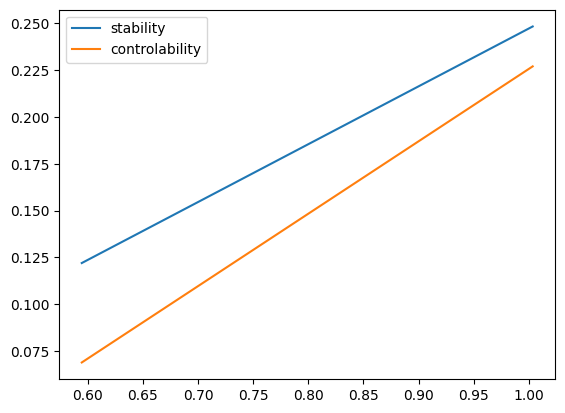

Stresses 36303231.13262954, 258250124.992756, 0.0004
Stresses 24318660.967550352, 181950494.35516796, 0.0005959183673469389
Stresses 18264599.750139225, 143808852.28447288, 0.0007918367346938775
Stresses 13851990.176439267, 41745407.205963105, 0.0004
Stresses 9240448.736129707, 28340407.066499606, 0.0005959183673469389
Stresses 6910907.183808392, 21572082.006997198, 0.0007918367346938775
Stresses 41533893.962782405, 294019317.19109476, 0.0004
Stresses 27821963.20444737, 205782749.1751038, 0.0005959183673469389
Stresses 20895317.769824483, 161549845.67221767, 0.0007918367346938775
Stresses 18196714.428487156, 54884947.38613946, 0.0004
Stresses 12156770.494353626, 37331886.64287473, 0.0005959183673469389
Stresses 9105664.795667626, 28471277.286928635, 0.0007918367346938775
Stresses 41869545.60014522, 296179718.6424109, 0.0004
Stresses 28046802.502210528, 207218972.9911195, 0.0005959183673469389
Stresses 21064179.700161025, 162616761.86383775, 0.0007918367346938775
Stresses 18495411.71205

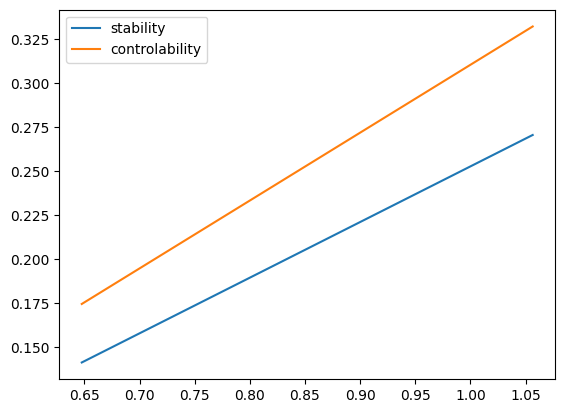

Stresses 36303231.13262954, 258250124.992756, 0.0004
Stresses 24318660.967550352, 181950494.35516796, 0.0005959183673469389
Stresses 18264599.750139225, 143808852.28447288, 0.0007918367346938775
Stresses 13851990.176439267, 41745407.205963105, 0.0004
Stresses 9240448.736129707, 28340407.066499606, 0.0005959183673469389
Stresses 6910907.183808392, 21572082.006997198, 0.0007918367346938775
Stresses 54470452.88133944, 378401350.65452117, 0.0004
Stresses 36487634.68727786, 262003336.92069715, 0.0005959183673469389
Stresses 27403530.651102424, 203445591.58125615, 0.0007918367346938775
Stresses 21923038.133409813, 168318553.81292042, 0.0009877551020408164
Stresses 31451570.800575957, 94970970.75147404, 0.0004
Stresses 21053865.867399536, 64763033.80975108, 0.0005959183673469389
Stresses 15801416.983630009, 49519297.18724351, 0.0007918367346938775
Stresses 12632584.185983956, 40335708.472224064, 0.0009877551020408164
Stresses 56246394.21498076, 388852425.1571923, 0.0004
Stresses 37677265.1187

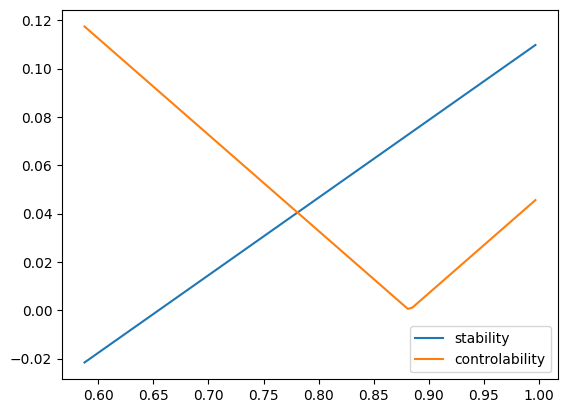

Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467

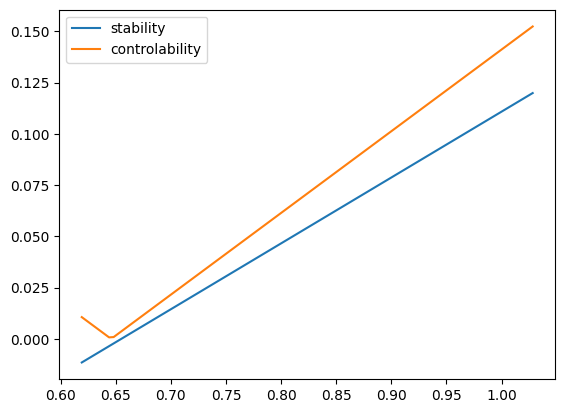

Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467

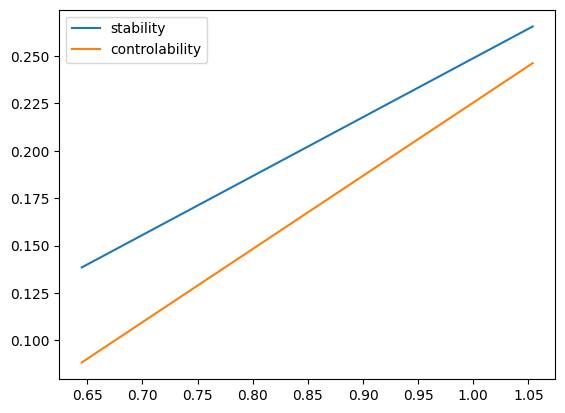

Stresses 36303231.13262954, 258250124.992756, 0.0004
Stresses 24318660.967550352, 181950494.35516796, 0.0005959183673469389
Stresses 18264599.750139225, 143808852.28447288, 0.0007918367346938775
Stresses 13851990.176439267, 41745407.205963105, 0.0004
Stresses 9240448.736129707, 28340407.066499606, 0.0005959183673469389
Stresses 6910907.183808392, 21572082.006997198, 0.0007918367346938775
Stresses 44227359.06747302, 312238957.1450193, 0.0004
Stresses 29626205.267472222, 217929052.9847095, 0.0005959183673469389
Stresses 22250364.68809037, 170602810.62785712, 0.0007918367346938775
Stresses 20661524.104686394, 62339152.50897134, 0.0004
Stresses 13811231.783857225, 42432851.53213118, 0.0005959183673469389
Stresses 10350774.838283734, 32385266.368272007, 0.0007918367346938775
Stresses 44722820.72463296, 315729040.219027, 0.0004
Stresses 29958094.75839002, 220260644.45327646, 0.0005959183673469389
Stresses 22499624.940391023, 172345017.06179002, 0.0007918367346938775
Stresses 17999886.9510197

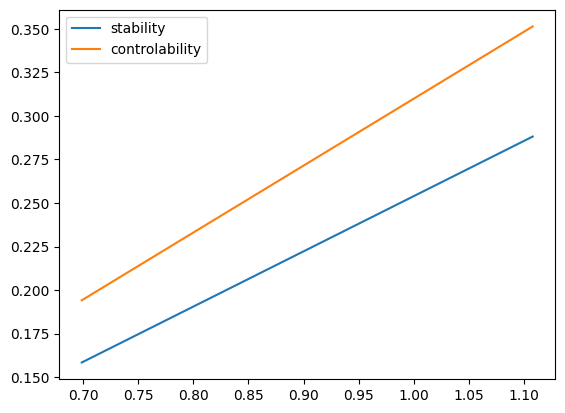

Stresses 36303231.13262954, 258250124.992756, 0.0004
Stresses 24318660.967550352, 181950494.35516796, 0.0005959183673469389
Stresses 18264599.750139225, 143808852.28447288, 0.0007918367346938775
Stresses 13851990.176439267, 41745407.205963105, 0.0004
Stresses 9240448.736129707, 28340407.066499606, 0.0005959183673469389
Stresses 6910907.183808392, 21572082.006997198, 0.0007918367346938775
Stresses 56565038.4440207, 391373045.56238437, 0.0004
Stresses 37890711.84945677, 270640219.23799676, 0.0005959183673469389
Stresses 28457289.13673894, 209880998.6713416, 0.0007918367346938775
Stresses 22766050.64063646, 173415736.4113799, 0.0009877551020408164
Stresses 18958808.336347207, 149187271.15819708, 0.0011836734693877551
Stresses 33934252.03637129, 102479223.97074944, 0.0004
Stresses 22720323.13526215, 69900984.19078654, 0.0005959183673469389
Stresses 17055554.927485384, 53461665.3721749, 0.0007918367346938775
Stresses 13637967.496347351, 43558244.08434621, 0.0009877551020408164
Stresses 5869

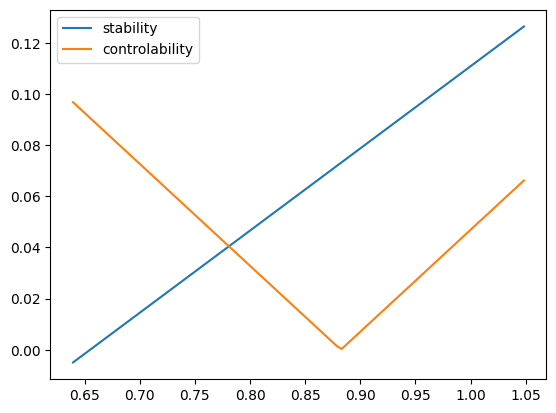

Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467

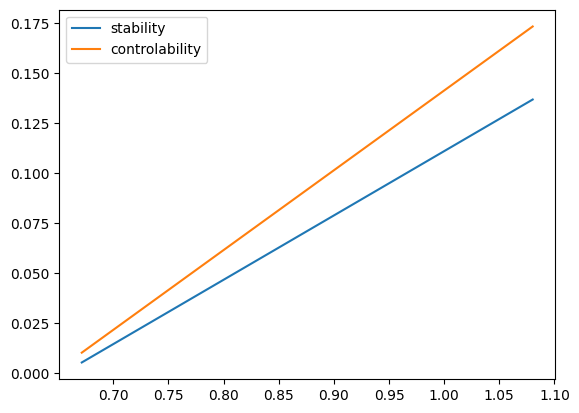

Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467

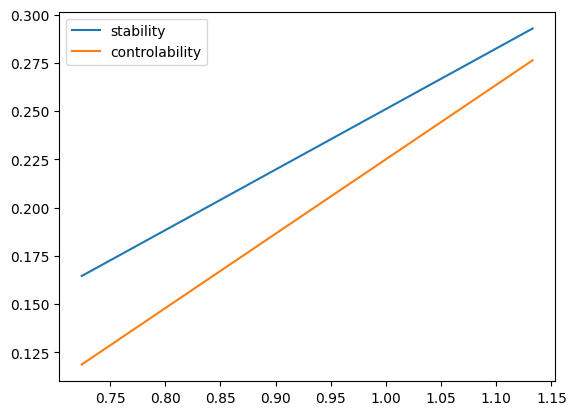

Stresses 36303231.13262954, 258250124.992756, 0.0004
Stresses 24318660.967550352, 181950494.35516796, 0.0005959183673469389
Stresses 18264599.750139225, 143808852.28447288, 0.0007918367346938775
Stresses 13851990.176439267, 41745407.205963105, 0.0004
Stresses 9240448.736129707, 28340407.066499606, 0.0005959183673469389
Stresses 6910907.183808392, 21572082.006997198, 0.0007918367346938775
Stresses 47874629.47090176, 334860204.33972883, 0.0004
Stresses 32069362.47221818, 232959200.8257901, 0.0005959183673469389
Stresses 24085258.52442962, 181767163.98466602, 0.0007918367346938775
Stresses 19268402.423697628, 151120613.14255312, 0.0009877551020408164
Stresses 24246385.565065548, 73180676.26662193, 0.0004
Stresses 16217508.654522683, 49851782.339981735, 0.0005959183673469389
Stresses 12161684.235794853, 38077839.206467256, 0.0007918367346938775
Stresses 9714781.90052932, 30983333.435671814, 0.0009877551020408164
Stresses 49191996.706753984, 343781006.99106616, 0.0004
Stresses 32951812.8795

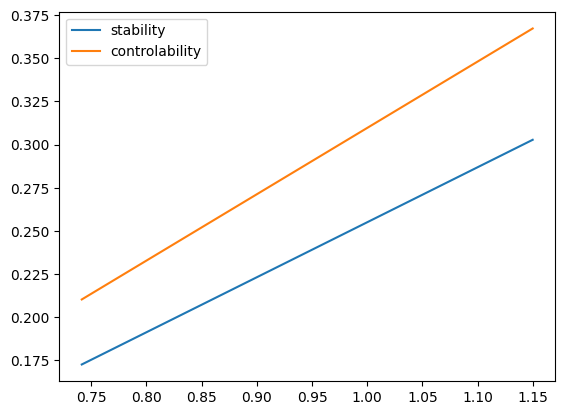

Stresses 36303231.13262954, 258250124.992756, 0.0004
Stresses 24318660.967550352, 181950494.35516796, 0.0005959183673469389
Stresses 18264599.750139225, 143808852.28447288, 0.0007918367346938775
Stresses 13851990.176439267, 41745407.205963105, 0.0004
Stresses 9240448.736129707, 28340407.066499606, 0.0005959183673469389
Stresses 6910907.183808392, 21572082.006997198, 0.0007918367346938775
Stresses 58250542.85680388, 410140517.3649479, 0.0004
Stresses 39019762.28807613, 283348419.7287547, 0.0005959183673469389
Stresses 29305244.268821884, 219524238.0324559, 0.0007918367346938775
Stresses 23444419.348114815, 181206249.61701196, 0.0009877551020408164
Stresses 19523729.573572822, 155735068.52914226, 0.0011836734693877551
Stresses 36000164.31008117, 108727062.90237686, 0.0004
Stresses 24107031.373779714, 74176424.22749065, 0.0005959183673469389
Stresses 18099160.09667902, 56742226.20427221, 0.0007918367346938775
Stresses 14474576.598924076, 46239811.00383741, 0.0009877551020408164
Stresses 6

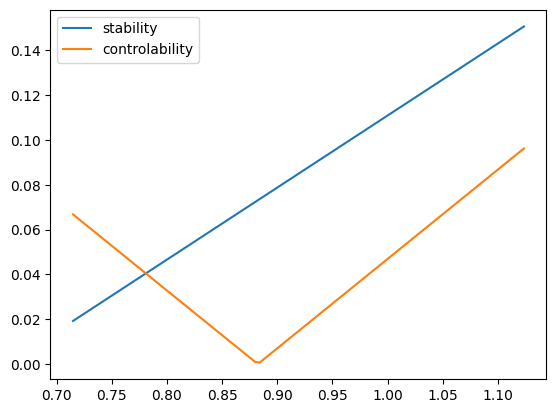

Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467

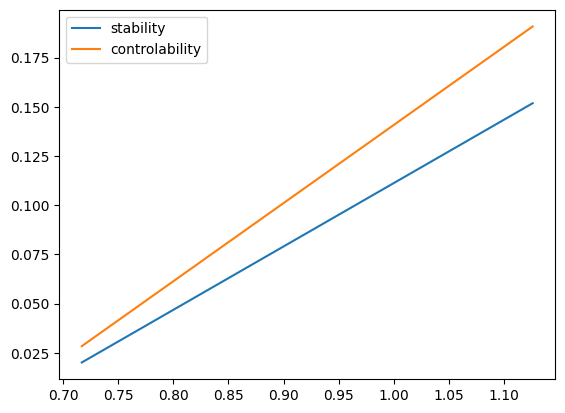

Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467859.77687751, 0.0004
Stresses 9844697.253156863, 30203400.47063397, 0.0005959183673469389
Stresses 7365650.913117488, 23001563.6836412, 0.0007918367346938775
Stresses 38642707.81017755, 274911602.7973105, 0.0004
Stresses 25888994.627822306, 193719816.54925644, 0.0005959183673469389
Stresses 19446397.247044913, 153135208.2885954, 0.0007918367346938775
Stresses 14752197.15078585, 44467

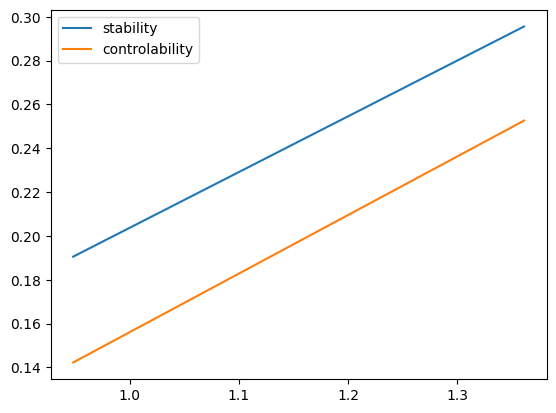

Stresses 36303231.132629536, 261174143.5814572, 0.0004
Stresses 24318660.967550337, 184010955.9854828, 0.0005959183673469389
Stresses 18264599.75013923, 145437656.84196132, 0.0007918367346938775
Stresses 13851990.17643927, 41987517.11256894, 0.0004
Stresses 9240448.736129709, 28504939.72526602, 0.0005959183673469389
Stresses 6910907.18380839, 21697450.07250736, 0.0007918367346938775
Stresses 48501673.23680916, 339877974.5973336, 0.0004
Stresses 32489393.433680516, 236330117.86760637, 0.0005959183673469389
Stresses 24400716.007357795, 184302309.8388461, 0.0007918367346938775
Stresses 19520770.122055657, 153148166.25407842, 0.0009877551020408164
Stresses 24891350.64810793, 75566556.7549323, 0.0004
Stresses 16650430.422592241, 51483312.255692616, 0.0005959183673469389
Stresses 12487491.339599773, 39328839.65147775, 0.0007918367346938775
Stresses 9975966.107711775, 32005197.063750714, 0.0009877551020408164
Stresses 49966618.599521235, 349509927.97873014, 0.0004
Stresses 33470700.389635354,

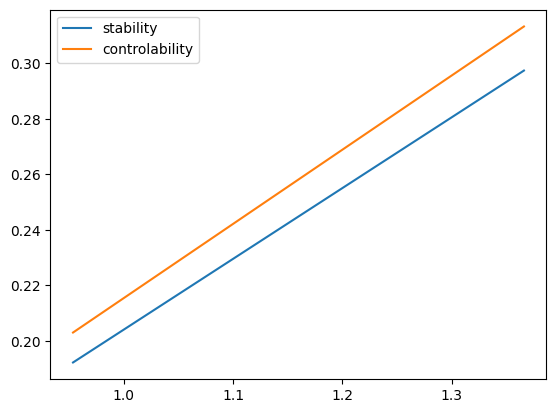

Stresses 36303231.132629536, 261174143.5814572, 0.0004
Stresses 24318660.967550337, 184010955.9854828, 0.0005959183673469389
Stresses 18264599.75013923, 145437656.84196132, 0.0007918367346938775
Stresses 13851990.17643927, 41987517.11256894, 0.0004
Stresses 9240448.736129709, 28504939.72526602, 0.0005959183673469389
Stresses 6910907.18380839, 21697450.07250736, 0.0007918367346938775
Stresses 56114568.15753614, 388673352.4289577, 0.0004
Stresses 37588960.236889295, 268844775.7185716, 0.0005959183673469389
Stresses 28230663.452232648, 208544834.20082244, 0.0007918367346938775
Stresses 22584748.863142274, 172358793.85612792, 0.0009877551020408164
Stresses 18807826.689750798, 148319018.19173717, 0.0011836734693877551
Stresses 33392399.10859298, 101424670.90827255, 0.0004
Stresses 22356613.635794528, 69178201.27807349, 0.0005959183673469389
Stresses 16781835.407267474, 52906192.94301879, 0.0007918367346938775
Stresses 13418539.451213986, 43103476.688568644, 0.0009877551020408164
Stresses 58

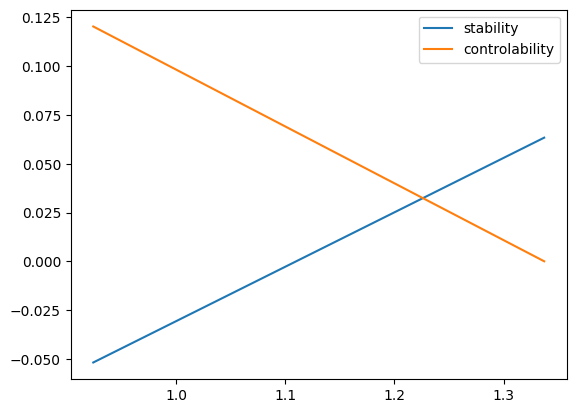

Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785

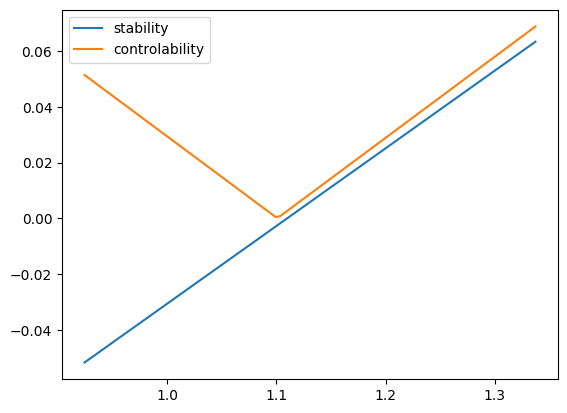

Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785

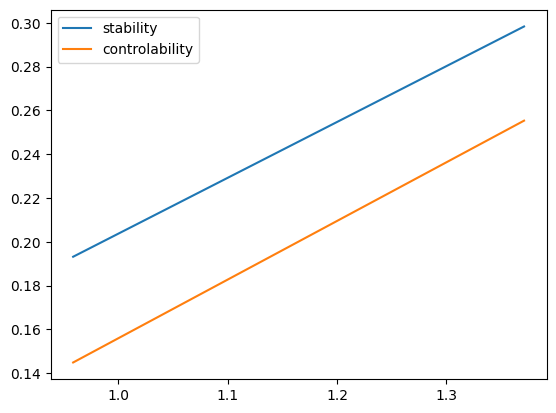

Stresses 36303231.132629536, 261174143.5814572, 0.0004
Stresses 24318660.967550337, 184010955.9854828, 0.0005959183673469389
Stresses 18264599.75013923, 145437656.84196132, 0.0007918367346938775
Stresses 13851990.17643927, 41987517.11256894, 0.0004
Stresses 9240448.736129709, 28504939.72526602, 0.0005959183673469389
Stresses 6910907.18380839, 21697450.07250736, 0.0007918367346938775
Stresses 48844717.40840229, 342498364.18859625, 0.0004
Stresses 32719184.687577937, 238087015.8214862, 0.0005959183673469389
Stresses 24573297.0244811, 185620813.98029304, 0.0007918367346938775
Stresses 19658835.872364808, 154200271.70546833, 0.0009877551020408164
Stresses 25247756.64534518, 76650656.79321983, 0.0004
Stresses 16889661.845395323, 52225169.52157442, 0.0005959183673469389
Stresses 12667531.482534051, 39898069.45439058, 0.0007918367346938775
Stresses 10120295.809072318, 32470491.837176275, 0.0009877551020408164
Stresses 50325849.672058046, 351008587.62033844, 0.0004
Stresses 33711334.586132035,

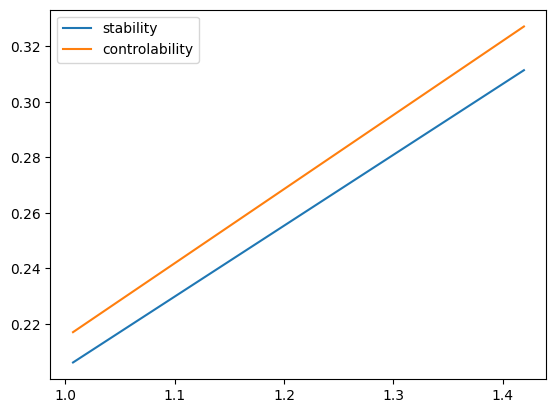

Stresses 36303231.132629536, 261174143.5814572, 0.0004
Stresses 24318660.967550337, 184010955.9854828, 0.0005959183673469389
Stresses 18264599.75013923, 145437656.84196132, 0.0007918367346938775
Stresses 13851990.17643927, 41987517.11256894, 0.0004
Stresses 9240448.736129709, 28504939.72526602, 0.0005959183673469389
Stresses 6910907.18380839, 21697450.07250736, 0.0007918367346938775
Stresses 57656595.890563756, 397952807.4929425, 0.0004
Stresses 38621901.51852855, 275018009.21105367, 0.0005959183673469389
Stresses 29006437.351211756, 213140626.5188008, 0.0007918367346938775
Stresses 23205372.19241736, 175995782.5274124, 0.0009877551020408164
Stresses 19324659.637913488, 151308267.47602737, 0.0011836734693877551
Stresses 35265236.68760322, 107121385.6292646, 0.0004
Stresses 23613723.79156853, 73076503.14890413, 0.0005959183673469389
Stresses 17727907.99872626, 55897374.27624998, 0.0007918367346938775
Stresses 14176961.280730538, 45548501.58641951, 0.0009877551020408164
Stresses 59952417

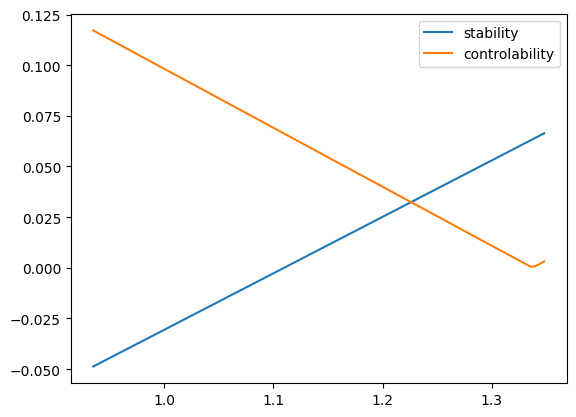

Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785

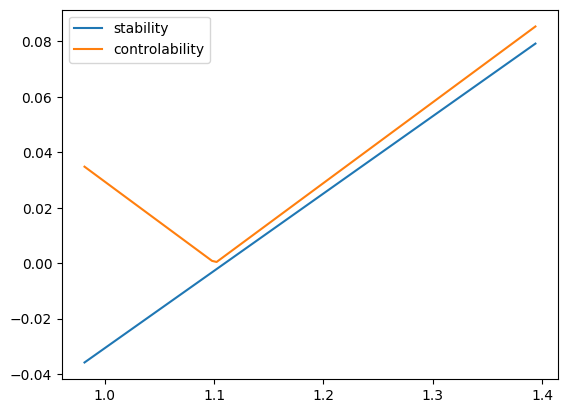

Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785

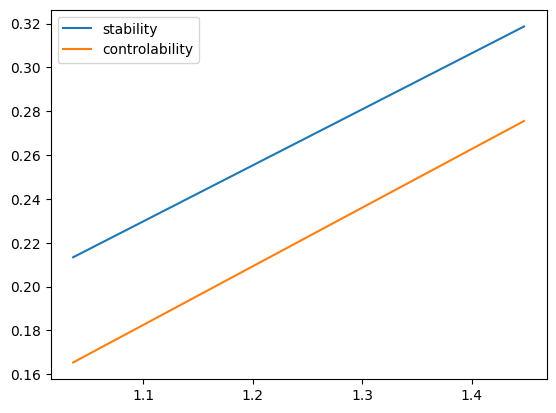

Stresses 36303231.132629536, 261174143.5814572, 0.0004
Stresses 24318660.967550337, 184010955.9854828, 0.0005959183673469389
Stresses 18264599.75013923, 145437656.84196132, 0.0007918367346938775
Stresses 13851990.17643927, 41987517.11256894, 0.0004
Stresses 9240448.736129709, 28504939.72526602, 0.0005959183673469389
Stresses 6910907.18380839, 21697450.07250736, 0.0007918367346938775
Stresses 51373102.53300526, 359080581.836895, 0.0004
Stresses 34412846.42623949, 249142171.06345087, 0.0005959183673469389
Stresses 25845294.372306287, 193866784.6671041, 0.0007918367346938775
Stresses 20676440.65381764, 160736596.38412595, 0.0009877551020408164
Stresses 27952233.41578113, 84877014.91599183, 0.0004
Stresses 18704995.568016704, 57854524.1287049, 0.0005959183673469389
Stresses 14033710.469661493, 44217493.90558112, 0.0007918367346938775
Stresses 11215497.14586043, 36001237.435985655, 0.0009877551020408164
Stresses 52971515.43917288, 368489518.7641305, 0.0004
Stresses 35483557.82827247, 255388

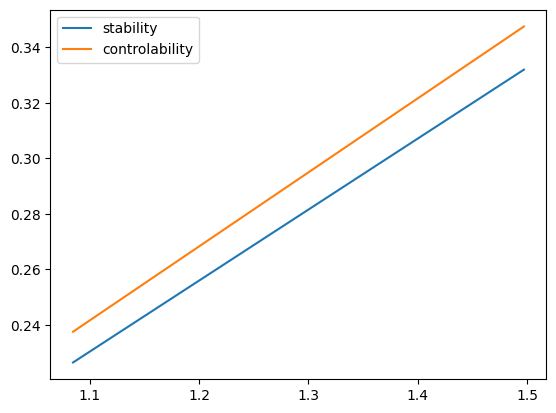

Stresses 36303231.132629536, 261174143.5814572, 0.0004
Stresses 24318660.967550337, 184010955.9854828, 0.0005959183673469389
Stresses 18264599.75013923, 145437656.84196132, 0.0007918367346938775
Stresses 13851990.17643927, 41987517.11256894, 0.0004
Stresses 9240448.736129709, 28504939.72526602, 0.0005959183673469389
Stresses 6910907.18380839, 21697450.07250736, 0.0007918367346938775
Iteration 0: Sh_S=0.27221605291135487, lh=4.5327979107792755, x_ac_h=-4.2827979107792755, x_cg=1.1925729548449466
Stresses 59843401.31016664, 419647526.4336857, 0.0004
Stresses 40086752.98934992, 289668964.08000344, 0.0005959183673469389
Stresses 30106590.435535368, 224226929.68996742, 0.0007918367346938775
Stresses 24085500.630341407, 184925882.43189466, 0.0009877551020408164
Stresses 20057599.17445306, 158790862.8843597, 0.0011836734693877551
Stresses 38008343.06067663, 115465245.57305788, 0.0004
Stresses 25454986.973494496, 78786265.0769463, 0.0005959183673469389
Stresses 19113600.908835504, 60278495.559

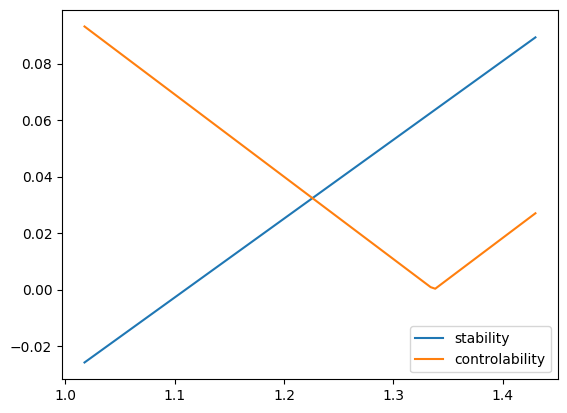

Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785

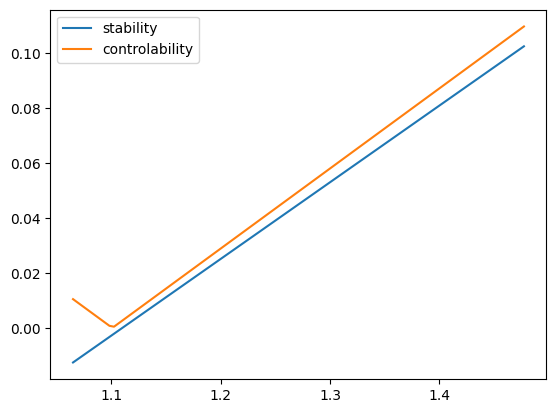

Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785848, 44725726.97132776, 0.0004
Stresses 9844697.25315687, 30378715.952078298, 0.0005959183673469389
Stresses 7365650.913117487, 23135205.448567804, 0.0007918367346938775
Stresses 38642707.81017753, 278024206.6805022, 0.0004
Stresses 25888994.627822295, 195913490.91843897, 0.0005959183673469389
Stresses 19446397.247044913, 154869574.52639785, 0.0007918367346938775
Stresses 14752197.150785

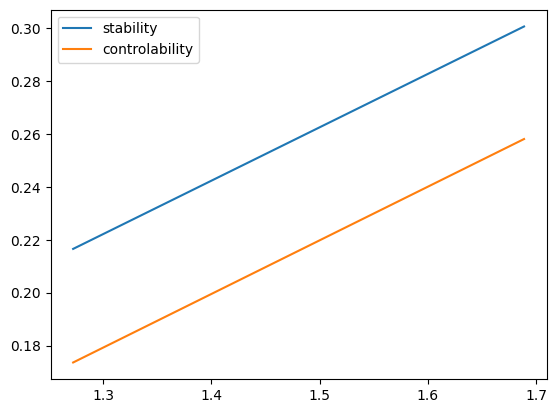

Stresses 36303231.13262954, 258005334.98031214, 0.0004
Stresses 24318660.967550352, 181777972.2738781, 0.0005959183673469389
Stresses 18264599.75013923, 143672451.7603514, 0.0007918367346938775
Stresses 13851990.17643927, 41390293.51611128, 0.0004
Stresses 9240448.736129705, 28099094.653538305, 0.0005959183673469389
Stresses 6910907.183808392, 21388222.209062297, 0.0007918367346938775
Stresses 51358708.35180012, 357677538.52086836, 0.0004
Stresses 34403204.353230745, 248171107.23738122, 0.0005959183673469389
Stresses 25838052.848798744, 193113072.730587, 0.0007918367346938775
Stresses 20670647.395711645, 160113293.79624996, 0.0009877551020408164
Stresses 27936449.9070021, 83623596.11741517, 0.0004
Stresses 18694401.158014342, 56999640.074100986, 0.0005959183673469389
Stresses 14025737.356979297, 43563716.78248976, 0.0007918367346938775
Stresses 11209105.477016028, 35468613.51319569, 0.0009877551020408164
Stresses 53035526.46134823, 369709148.0184088, 0.0004
Stresses 35526436.19282603, 

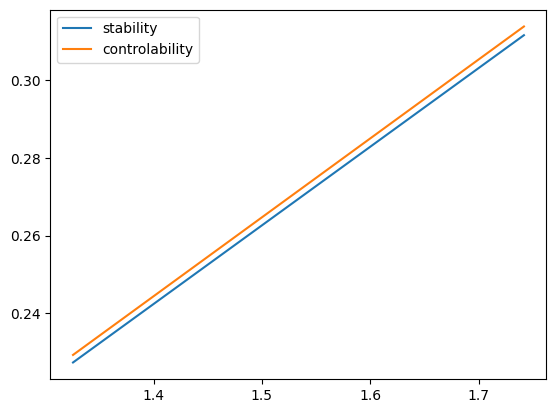

Stresses 36303231.13262954, 258005334.98031214, 0.0004
Stresses 24318660.967550352, 181777972.2738781, 0.0005959183673469389
Stresses 18264599.75013923, 143672451.7603514, 0.0007918367346938775
Stresses 13851990.17643927, 41390293.51611128, 0.0004
Stresses 9240448.736129705, 28099094.653538305, 0.0005959183673469389
Stresses 6910907.183808392, 21388222.209062297, 0.0007918367346938775
Stresses 58242417.66564345, 403531317.99310213, 0.0004
Stresses 39014319.554984674, 278782344.9887868, 0.0005959183673469389
Stresses 29301156.59186825, 215986629.60499883, 0.0007918367346938775
Stresses 23441149.184368294, 178286103.42749313, 0.0009877551020408164
Stresses 19521006.29797175, 153225372.42706582, 0.0011836734693877551
Stresses 35990059.621571496, 107772945.30190232, 0.0004
Stresses 24100248.774643112, 73525209.23386997, 0.0005959183673469389
Stresses 18094055.66640094, 56243846.65175234, 0.0007918367346938775
Stresses 14470484.61762677, 45833492.731279984, 0.0009877551020408164
Stresses 60

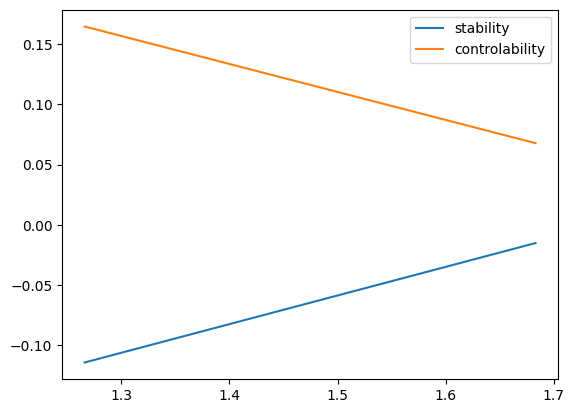

Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 4

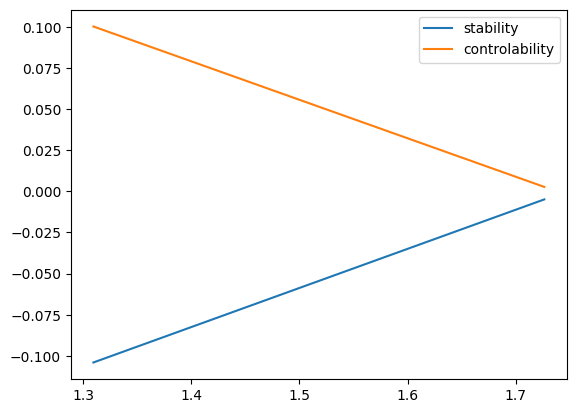

Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 4

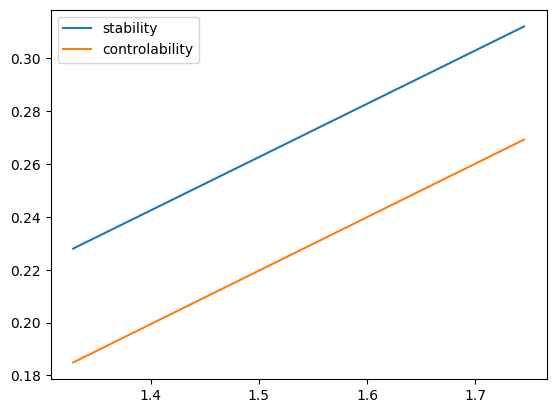

Stresses 36303231.13262954, 258005334.98031214, 0.0004
Stresses 24318660.967550352, 181777972.2738781, 0.0005959183673469389
Stresses 18264599.75013923, 143672451.7603514, 0.0007918367346938775
Stresses 13851990.17643927, 41390293.51611128, 0.0004
Stresses 9240448.736129705, 28099094.653538305, 0.0005959183673469389
Stresses 6910907.183808392, 21388222.209062297, 0.0007918367346938775
Stresses 52734504.001533635, 373055124.0313069, 0.0004
Stresses 35324793.564226426, 258595208.82369187, 0.0005959183673469389
Stresses 26530197.57012273, 201030780.6394588, 0.0007918367346938775
Stresses 21224366.92905192, 166515204.23863825, 0.0009877551020408164
Stresses 29465059.667365927, 88207246.45287412, 0.0004
Stresses 19720454.284833897, 60136264.17291862, 0.0005959183673469389
Stresses 14797921.668915663, 45970459.96570744, 0.0007918367346938775
Stresses 11828129.2642708, 37435912.16551224, 0.0009877551020408164
Stresses 54476568.130710974, 377520980.598154, 0.0004
Stresses 36491731.04260818, 26

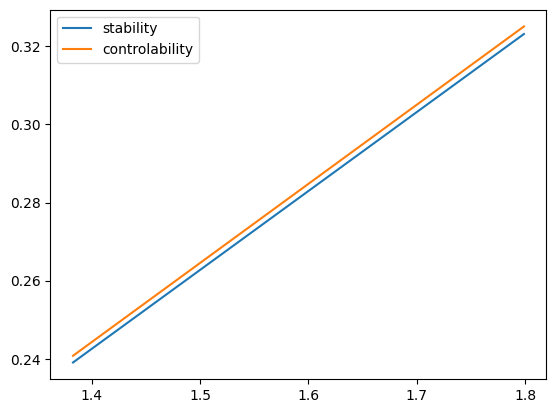

Stresses 36303231.13262954, 258005334.98031214, 0.0004
Stresses 24318660.967550352, 181777972.2738781, 0.0005959183673469389
Stresses 18264599.75013923, 143672451.7603514, 0.0007918367346938775
Stresses 13851990.17643927, 41390293.51611128, 0.0004
Stresses 9240448.736129705, 28099094.653538305, 0.0005959183673469389
Stresses 6910907.183808392, 21388222.209062297, 0.0007918367346938775
Stresses 59483907.61417081, 410215578.3407371, 0.0004
Stresses 39845942.872178584, 283210789.34897166, 0.0005959183673469389
Stresses 29925733.87880101, 219268903.14028624, 0.0007918367346938775
Stresses 23940814.40345755, 180871225.38411245, 0.0009877551020408164
Stresses 19937109.650986407, 155339110.28405476, 0.0011836734693877551
Stresses 37550375.604295336, 112451669.10903801, 0.0004
Stresses 25147584.160307072, 76726892.77671029, 0.0005959183673469389
Stresses 18882256.523653194, 58700510.18515312, 0.0007918367346938775
Stresses 15102348.114762887, 47841596.83318633, 0.0009877551020408164
Stresses 6

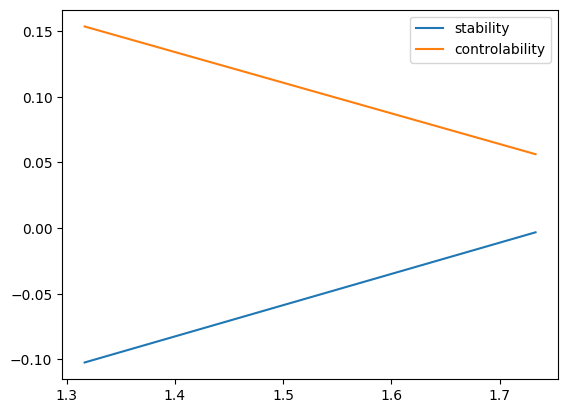

Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 4

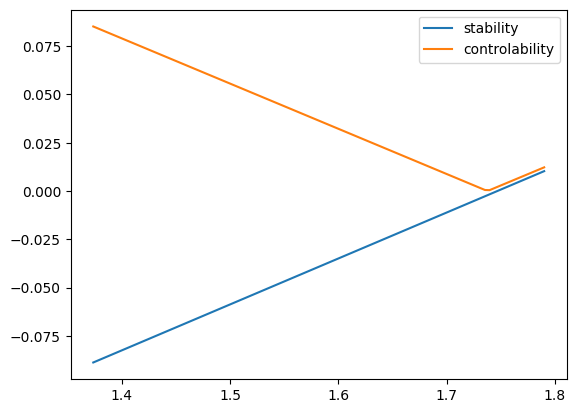

Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 4

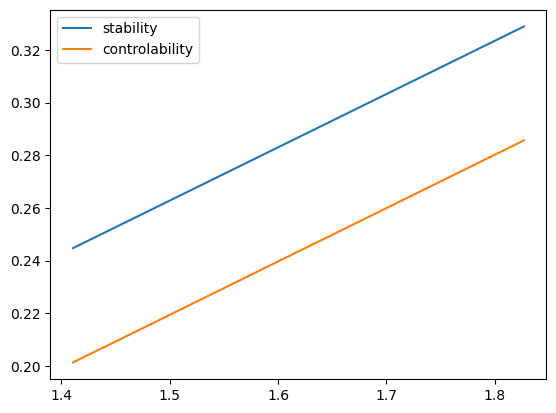

Stresses 36303231.13262954, 258005334.98031214, 0.0004
Stresses 24318660.967550352, 181777972.2738781, 0.0005959183673469389
Stresses 18264599.75013923, 143672451.7603514, 0.0007918367346938775
Stresses 13851990.17643927, 41390293.51611128, 0.0004
Stresses 9240448.736129705, 28099094.653538305, 0.0005959183673469389
Stresses 6910907.183808392, 21388222.209062297, 0.0007918367346938775
Stresses 54695301.07095516, 380230890.27318317, 0.0004
Stresses 36638251.28916415, 263232739.99778536, 0.0005959183673469389
Stresses 27516648.82207389, 204370793.41564476, 0.0007918367346938775
Stresses 22013533.28407728, 169059329.33098945, 0.0009877551020408164
Stresses 31713585.940088827, 94949620.1256691, 0.0004
Stresses 21229739.043236934, 64750117.804318056, 0.0005959183673469389
Stresses 15933775.146889077, 49510686.79107697, 0.0007918367346938775
Stresses 12738689.490414778, 40329732.95661674, 0.0009877551020408164
Stresses 56528354.72964539, 390966171.4956371, 0.0004
Stresses 37866138.93022147, 

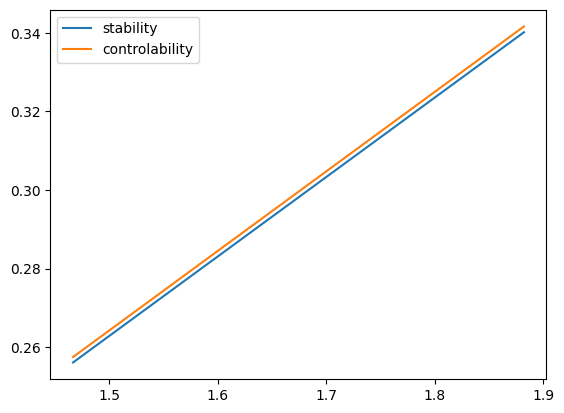

Stresses 36303231.13262954, 258005334.98031214, 0.0004
Stresses 24318660.967550352, 181777972.2738781, 0.0005959183673469389
Stresses 18264599.75013923, 143672451.7603514, 0.0007918367346938775
Stresses 13851990.17643927, 41390293.51611128, 0.0004
Stresses 9240448.736129705, 28099094.653538305, 0.0005959183673469389
Stresses 6910907.183808392, 21388222.209062297, 0.0007918367346938775
Stresses 61263358.299309134, 422908971.90024865, 0.0004
Stresses 41037924.07451676, 291708597.94474864, 0.0005959183673469389
Stresses 30820952.146528862, 225639885.90029907, 0.0007918367346938775
Stresses 24656993.875924557, 185952739.4748899, 0.0009877551020408164
Stresses 20533518.343175482, 159552376.9284605, 0.0011836734693877551
Stresses 39844270.10148484, 119330082.7854281, 0.0004
Stresses 26687321.56253014, 81433839.5374828, 0.0005959183673469389
Stresses 20041027.970687058, 62312167.71036563, 0.0007918367346938775
Stresses 16031280.597095817, 50793805.87298934, 0.0009877551020408164
Stresses 6379

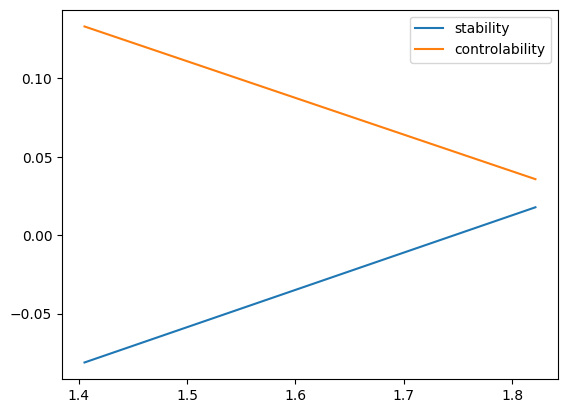

Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 4

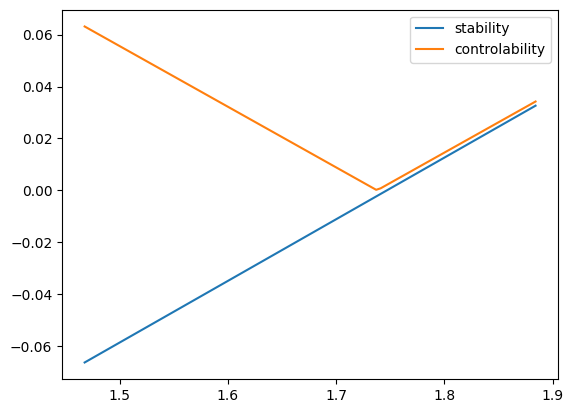

Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 44089631.24568594, 0.0004
Stresses 9844697.253156867, 29946270.40949265, 0.0005959183673469389
Stresses 7365650.913117488, 22805566.946203057, 0.0007918367346938775
Stresses 38642707.81017754, 274651029.8997091, 0.0004
Stresses 25888994.627822302, 193536145.76538754, 0.0005959183673469389
Stresses 19446397.247044917, 152989973.2056505, 0.0007918367346938775
Stresses 14752197.15078585, 4

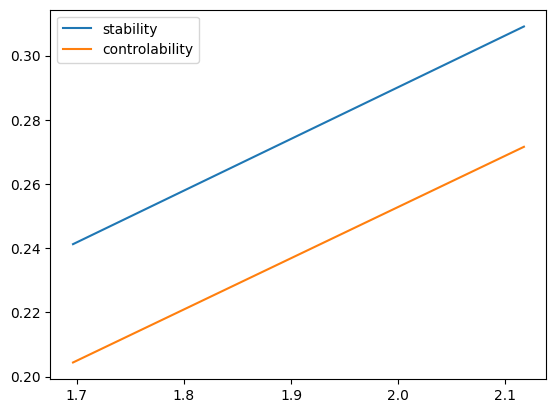

Stresses 50901135.208114795, 561025441.3555032, 0.0004
Stresses 34105567.25167551, 400112090.7427982, 0.0005959183673469389
Stresses 25621208.180896908, 320193504.4560252, 0.0007918367346938775
Stresses 15881863.844658105, 47477021.052154206, 0.0004
Stresses 10602966.677810842, 32264285.031346157, 0.0005959183673469389
Stresses 7936307.284248831, 24584188.07324467, 0.0007918367346938775
Stresses 71278249.441713, 756917407.1577122, 0.0004
Stresses 47758914.18324248, 529949115.23474234, 0.0005959183673469389
Stresses 35878012.8671078, 416183827.28645307, 0.0007918367346938775
Stresses 28710196.37059684, 348299099.78081834, 0.0009877551020408164
Stresses 23915174.300517038, 303545161.7400639, 0.0011836734693877551
Stresses 31342592.438807897, 93837168.45180656, 0.0004
Stresses 20980716.008130565, 63988859.315202124, 0.0005959183673469389
Stresses 15746366.058613153, 48926570.358369276, 0.0007918367346938775
Stresses 12588452.452705983, 39852269.68638718, 0.0009877551020408164
Stresses 735

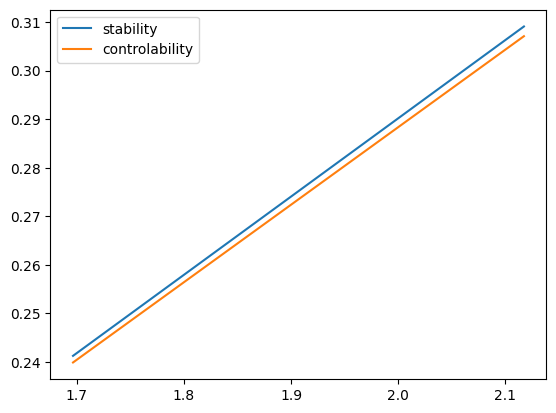

Stresses 50901135.208114795, 561025441.3555032, 0.0004
Stresses 34105567.25167551, 400112090.7427982, 0.0005959183673469389
Stresses 25621208.180896908, 320193504.4560252, 0.0007918367346938775
Stresses 15881863.844658105, 47477021.052154206, 0.0004
Stresses 10602966.677810842, 32264285.031346157, 0.0005959183673469389
Stresses 7936307.284248831, 24584188.07324467, 0.0007918367346938775
Stresses 76999574.27053063, 812188026.924329, 0.0004
Stresses 51592392.85401526, 566724837.5255462, 0.0005959183673469389
Stresses 38757837.29309515, 443534289.965964, 0.0007918367346938775
Stresses 31014675.67369701, 369891091.1371066, 0.0009877551020408164
Stresses 25834767.55589271, 321219603.5291323, 0.0011836734693877551
Stresses 36612148.38972109, 109638324.85445441, 0.0004
Stresses 24517815.208058603, 74801701.55544028, 0.0005959183673469389
Stresses 18408306.69361054, 57223303.895139314, 0.0007918367346938775
Stresses 14722404.862579921, 46634111.978216305, 0.0009877551020408164
Stresses 7955957

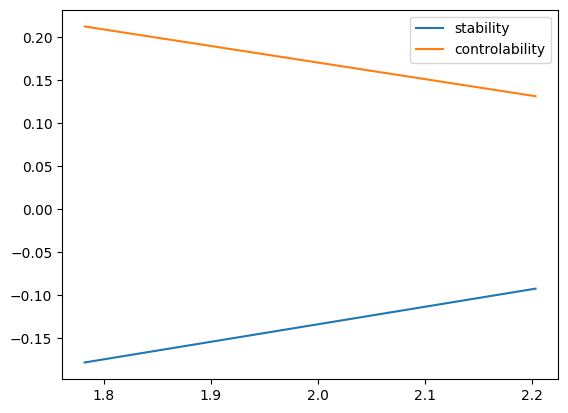

Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 56058648.17502553, 617084164.2483327, 0.0004
Stresses 37565342.19037914, 439193768.13452965, 0.0005959183673469389
Stresses 28223362.87854744, 350734445.88281053, 0.0007918367346938775
Stresses 18120171.763885457, 54188754.23014004, 0.0004
Stresses 12105392.541401802, 36857171.157071196, 0.0005959183673469389
Stresses 9066998.913549246, 28108326.454554264, 0.0007918367346938775
Stresses 56057326.11539472, 616139243.5400026, 0.0004
Stresses 37564456.27031977, 438522196.56200176, 0.0005959183673469389
Stresses 28222697.27641593, 350198910.0304199, 0.0007918367346938775
Stresses 18119307.391120255, 541861

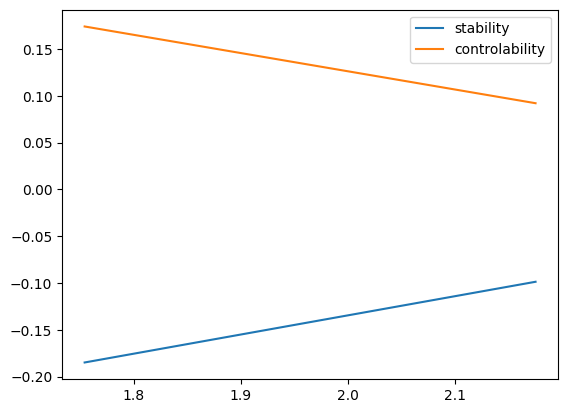

Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994

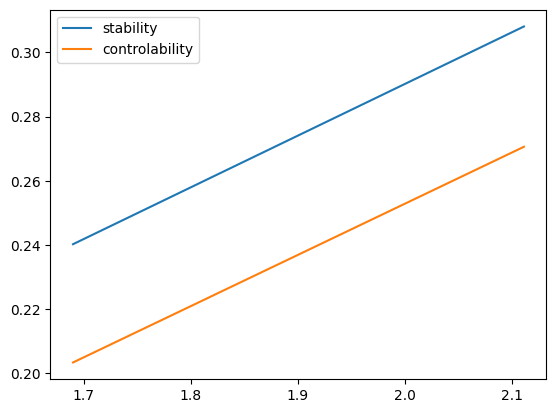

Stresses 50901135.208114795, 561025441.3555032, 0.0004
Stresses 34105567.25167551, 400112090.7427982, 0.0005959183673469389
Stresses 25621208.180896908, 320193504.4560252, 0.0007918367346938775
Stresses 15881863.844658105, 47477021.052154206, 0.0004
Stresses 10602966.677810842, 32264285.031346157, 0.0005959183673469389
Stresses 7936307.284248831, 24584188.07324467, 0.0007918367346938775
Stresses 71119942.74297342, 769343456.1453243, 0.0004
Stresses 47652843.4092127, 538705938.1818684, 0.0005959183673469389
Stresses 35798329.3127769, 423106235.1907487, 0.0007918367346938775
Stresses 28646432.37856354, 354131020.406499, 0.0009877551020408164
Stresses 23862059.94671046, 308661892.80359006, 0.0011836734693877551
Stresses 31202574.603607394, 93417314.53360686, 0.0004
Stresses 20886731.433817886, 63701550.33187486, 0.0005959183673469389
Stresses 15675635.399594342, 48706117.12096648, 0.0007918367346938775
Stresses 12531751.015310738, 39672068.757652655, 0.0009877551020408164
Stresses 7334776

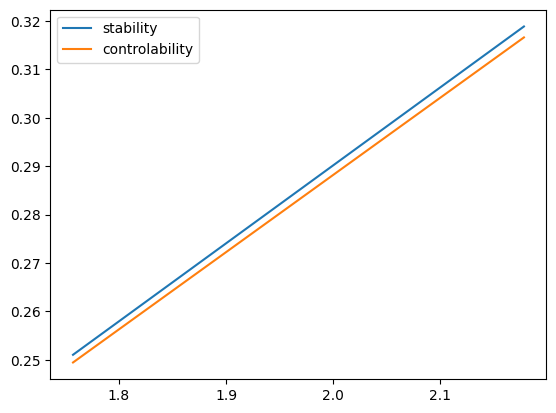

Stresses 50901135.208114795, 561025441.3555032, 0.0004
Stresses 34105567.25167551, 400112090.7427982, 0.0005959183673469389
Stresses 25621208.180896908, 320193504.4560252, 0.0007918367346938775
Stresses 15881863.844658105, 47477021.052154206, 0.0004
Stresses 10602966.677810842, 32264285.031346157, 0.0005959183673469389
Stresses 7936307.284248831, 24584188.07324467, 0.0007918367346938775
Stresses 78373031.90565139, 829345718.3633943, 0.0004
Stresses 52512655.329385296, 578270813.814821, 0.0005959183673469389
Stresses 39449166.13106533, 452231455.6286869, 0.0007918367346938775
Stresses 31567887.5238144, 376857207.970539, 0.0009877551020408164
Stresses 26295583.90379141, 327016472.8750368, 0.0011836734693877551
Stresses 37937755.54227647, 113613256.73507446, 0.0004
Stresses 25407606.310458783, 77521775.34280154, 0.0005959183673469389
Stresses 19077943.296447802, 59310426.495532736, 0.0007918367346938775
Stresses 15259220.982209785, 48340149.210441425, 0.0009877551020408164
Stresses 809819

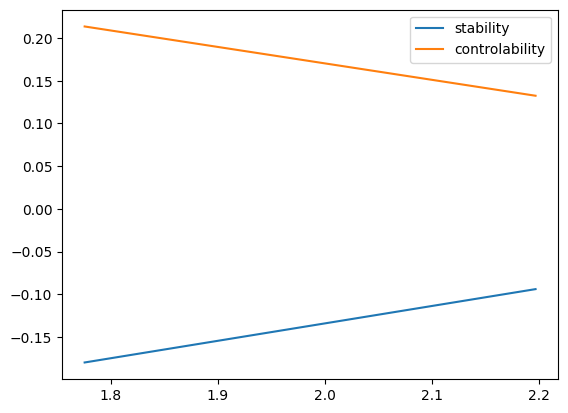

Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 56276036.74719472, 618933095.6345062, 0.0004
Stresses 37711015.57172169, 440403184.7966291, 0.0005959183673469389
Stresses 28332808.99854462, 351613316.52015877, 0.0007918367346938775
Stresses 18262579.818073995, 54615775.398183584, 0.0004
Stresses 12200981.509281777, 37149384.73977603, 0.0005959183673469389
Stresses 9138937.002778497, 28332543.009060603, 0.0007918367346938775
Stresses 56274696.19850981, 619069137.3026, 0.0004
Stresses 37710117.26203673, 440500099.6926608, 0.0005959183673469389
Stresses 28332134.08794207, 351690793.3943878, 0.0007918367346938775
Stresses 18261699.952547602, 54613137.05

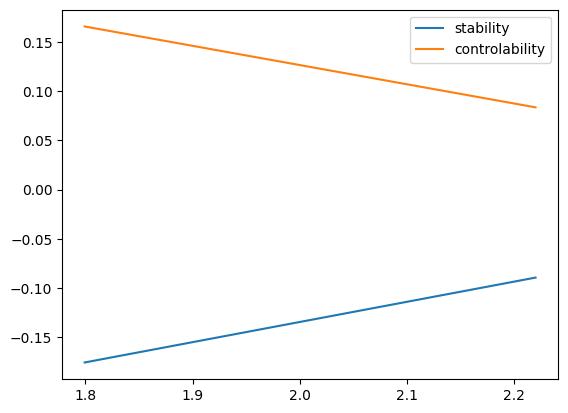

Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994

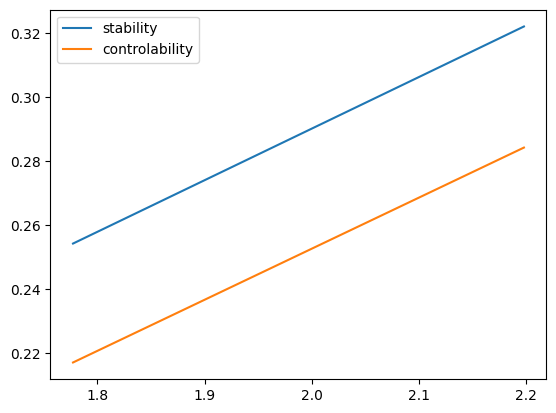

Stresses 50901135.208114795, 561025441.3555032, 0.0004
Stresses 34105567.25167551, 400112090.7427982, 0.0005959183673469389
Stresses 25621208.180896908, 320193504.4560252, 0.0007918367346938775
Stresses 15881863.844658105, 47477021.052154206, 0.0004
Stresses 10602966.677810842, 32264285.031346157, 0.0005959183673469389
Stresses 7936307.284248831, 24584188.07324467, 0.0007918367346938775
Stresses 73242901.73396918, 776964735.4781383, 0.0004
Stresses 49075296.81895347, 543319914.0987713, 0.0005959183673469389
Stresses 36866919.078378536, 426153135.94553244, 0.0007918367346938775
Stresses 29501534.160511084, 356190979.33258307, 0.0009877551020408164
Stresses 24574345.629247993, 310024352.05432296, 0.0011836734693877551
Stresses 33106211.206903145, 99125510.81858394, 0.0004
Stresses 22164514.90726299, 67607709.11753364, 0.0005959183673469389
Stresses 16637266.261053018, 51703327.09378208, 0.0007918367346938775
Stresses 13302645.176975962, 42122021.53256679, 0.0009877551020408164
Stresses 7

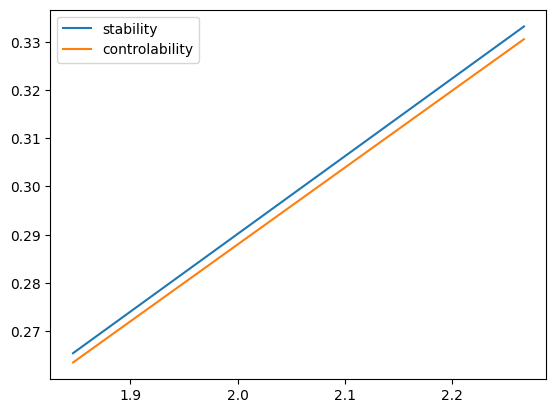

Stresses 50901135.208114795, 561025441.3555032, 0.0004
Stresses 34105567.25167551, 400112090.7427982, 0.0005959183673469389
Stresses 25621208.180896908, 320193504.4560252, 0.0007918367346938775
Stresses 15881863.844658105, 47477021.052154206, 0.0004
Stresses 10602966.677810842, 32264285.031346157, 0.0005959183673469389
Stresses 7936307.284248831, 24584188.07324467, 0.0007918367346938775
Stresses 80355237.14799392, 844624378.601865, 0.0004
Stresses 53840799.0277081, 588324139.1873058, 0.0005959183673469389
Stresses 40446907.606120385, 459617047.2407962, 0.0007918367346938775
Stresses 32366295.42615425, 382608962.5640333, 0.0009877551020408164
Stresses 26960644.51955625, 331653352.56255865, 0.0011836734693877551
Stresses 39892268.63563311, 119474009.96871258, 0.0004
Stresses 26719539.75668448, 81532329.91928019, 0.0005959183673469389
Stresses 20065274.652885683, 62387739.74180314, 0.0007918367346938775
Stresses 16050718.020015374, 50855579.29220435, 0.0009877551020408164
Stresses 8303259

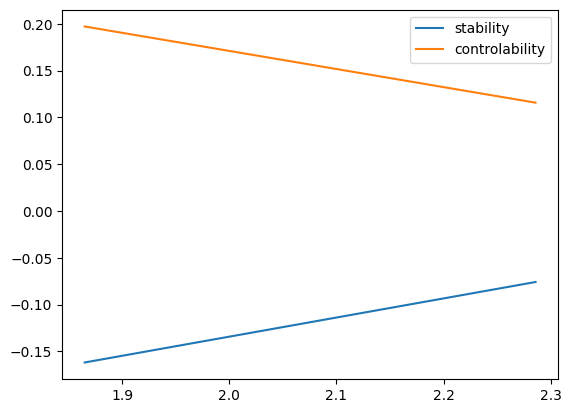

Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994

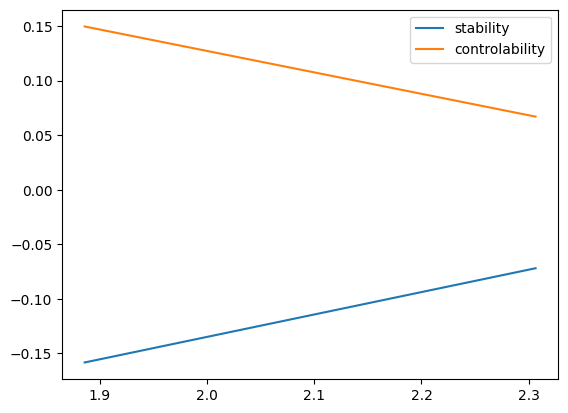

Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994, 0.0004
Stresses 11294658.56129356, 34378773.4276863, 0.0005959183673469389
Stresses 8456858.907900777, 26206642.78045771, 0.0007918367346938775
Stresses 54179754.21397238, 597198628.4241856, 0.0004
Stresses 36306284.118621, 425969113.16914207, 0.0005959183673469389
Stresses 27277417.78179403, 340933289.3058845, 0.0007918367346938775
Stresses 16912343.58943848, 50566991.39665994

In [ ]:
aircraft:list[Aircraft] = list()

for i, planform_recovered in enumerate(plaforms_recovered):
    main_wing = planform_recovered[0]
    planform_type = planform_recovered[1]

    ef = TailFinder(fixed, material=material_skin, core_density=assumptions.foam_denisty, thicknesses=assumptions.allowable_thicknesses, safety_factor=assumptions.structural_safety_factor, AR_h=5., Sv_S=0.2) if (planform_type == "tail") else CanardFinder(fixed, material=material_skin, core_density=assumptions.foam_denisty, thicknesses=assumptions.allowable_thicknesses, safety_factor=assumptions.structural_safety_factor, AR_c=9.)#max(9., main_wing.aspect_ratio/2)) #NOTE: based on long ez canard
    
    emp = ef.find_planforms(main_wing, print_=i==43)

    for e in emp:
        e.add_cache_entry("go_around", assumptions.airspeed_approach/asb.Atmosphere(assumptions.altitude_go_round).speed_of_sound(), assumptions.altitude_go_round)
        e.add_cache_entry("mach_max", assumptions.mach_max, assumptions.altitude_mach_max)
        e.add_cache_entry("cruise", assumptions.mach_cruise, assumptions.altitude_cruise)
        e.add_cache_entry("takeoff", assumptions.airspeed_approach/asb.Atmosphere().speed_of_sound(), 0.)
        e.mass_cache = 1
        e.x_cg_cache = .1

    aircraft_planforms = [main_wing] + emp #TODO add the empenage
    aircraft.append(Aircraft(
        fixed=fixed, #TODO: add the fuselage from CAD
        planforms=aircraft_planforms 
    ))

In [10]:
s_ratios = [ac.planforms[1].wing_area / ac.planforms[0].wing_area for ac in aircraft]
print(s_ratios)
print(min(s_ratios), np.average(s_ratios), max(s_ratios))
ac_bad:Aircraft = aircraft[np.argmax(s_ratios)],
print(np.argmax(s_ratios))
ac_bad= ac_bad[0]
print(plaforms_recovered[np.argmax(s_ratios)][1])
print(ac_bad.planforms[0].sweep_quarter_rad, ac_bad.planforms[0].aspect_ratio, ac_bad.planforms[0].cm_quarter_chord, ac_bad.planforms[0].thickness_to_chord)

[0.18656706852330998, 0.13325706559254924, 0.2516376139414324, 0.24450920345554455, 0.10000000000000003, 0.1, 0.10000000000000003, 0.1, 0.2034103888804631, 0.15374105796734214, 0.27106466276972285, 0.26385252309196366, 0.10000000000000003, 0.1, 0.10000000000000003, 0.1, 0.2300594274861516, 0.18467939342567138, 0.2871115186538556, 0.27993106575561877, 0.10000000000000003, 0.1, 0.10782607873905908, 0.1, 0.24465048355579308, 0.19072339597122354, 0.25639441342573654, 0.26090768421754157, 0.10000000000000002, 0.10000000000000002, 0.10000000000000002, 0.10000000000000002, 0.24732783449181212, 0.1934839732256725, 0.2704399615495008, 0.275567950077921, 0.10000000000000002, 0.10000000000000002, 0.10000000000000002, 0.10000000000000002, 0.26757550860688945, 0.2144233777659927, 0.2908636249185065, 0.2970048375758708, 0.10000000000000002, 0.10000000000000002, 0.10000000000000002, 0.10000000000000002, 0.2602552218436586, 0.21506763505642756, 0.27109790495997693, 0.28207054880267485, 0.1181188116598

# Checking if reuirements are met

In [11]:
for ac in aircraft:
    ac.fixed = fixed

In [12]:
requirements:list[Requirement] = [
    MassReq(50.),
    MDReq(),
    FuelReq(),
    LGReq(),
    EmpennageReq(),
]

requirement_labels = [
    "MTOM",
    "Matching Diagram",
    "Fuel",
    "Landing Gear",
    "Empennage Requirement"
]

In [13]:
for ac in aircraft:
    failed_reqs = list()
    for requirement, label in zip(requirements, requirement_labels):
        # if type(requirement) == LGReq:
        #         print("f")
        if not requirement.assess(ac):
            failed_reqs.append(label)

    if len(failed_reqs):
        print(f"ac mass: {ac.total_mass()}, {ac.planforms[0].oswald}")
        print(f"MainWing: AR={ac.planforms[0].aspect_ratio}, tc={ac.planforms[0].thickness_to_chord}, sweep={np.rad2deg(ac.planforms[0].sweep_quarter_rad)} deg, cmac={ac.planforms[0].cm_quarter_chord}")
        print(f"Failed: {failed_reqs}")
        print()